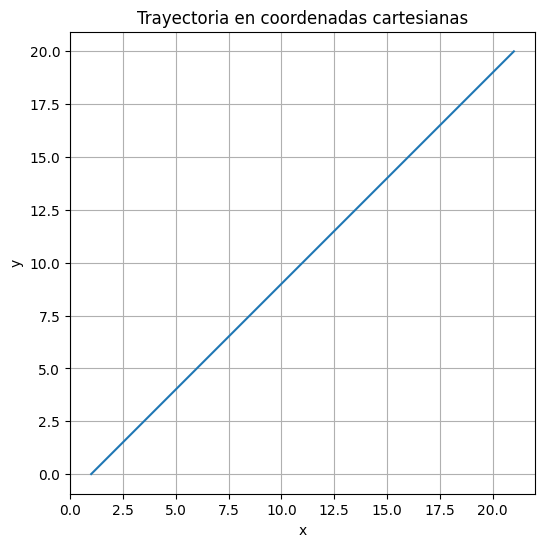

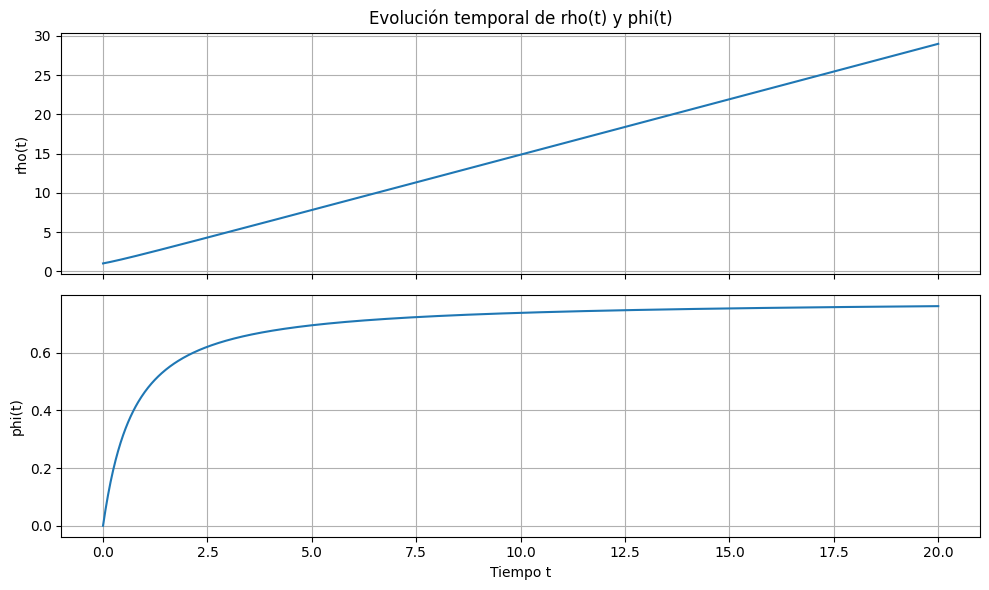

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Ecuaciones de Hamilton para una partícula libre en coordenadas cilíndricas
def hamilton_eqs(y, t, m):
    rho, prho, phi, pphi = y
    drho_dt = prho / m
    dprho_dt = pphi**2 / (m * rho**3)
    dphi_dt = pphi / (m * rho**2)
    dpphi_dt = 0  # pphi es constante
    return [drho_dt, dprho_dt, dphi_dt, dpphi_dt]

# Parámetros y condiciones iniciales
m = 1.0
rho0 = 1.0
prho0 = 1.0
phi0 = 0.0
pphi0 = 1.0
y0 = [rho0, prho0, phi0, pphi0]
t = np.linspace(0, 20, 1000)

# Resolver con odeint
sol = odeint(hamilton_eqs, y0, t, args=(m,))
rho, prho, phi, pphi = sol.T

# Convertir a coordenadas cartesianas
x = rho * np.cos(phi)
y = rho * np.sin(phi)

# --- GRAFICA 1: Trayectoria en coordenadas cartesianas ---
plt.figure(figsize=(6, 6))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectoria en coordenadas cartesianas')
plt.axis('equal')
plt.grid(True)
plt.show()

# --- GRAFICA 2: Trayectoria en coordenadas polares ---
#plt.figure(figsize=(6, 6))
#ax = plt.subplot(111, projection='polar')
#ax.plot(phi, rho)
#ax.set_title('Trayectoria en coordenadas polares')
#ax.grid(True)
#plt.show()

# --- GRAFICA 3: Evolución de rho(t) y phi(t) ---
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(t, rho)
axs[0].set_ylabel('rho(t)')
axs[0].set_title('Evolución temporal de rho(t) y phi(t)')
axs[0].grid(True)

axs[1].plot(t, phi)
axs[1].set_ylabel('phi(t)')
axs[1].set_xlabel('Tiempo t')
axs[1].grid(True)

plt.tight_layout()
plt.show()
